# Supervised Learning

In this notebook we try to include everything about supervised learning and have a complete understanding of what it is.


In supervised learning we can have both regression and classification problems. In this method we predict a **target variable** for which we get to see **examples**.


### Linear Regression:

+ **Definition**: A form of machine learning where the model learns from labeled data ${(x_i, y_i)}$ to predict an output $y$ given an input $x$.
+ **Goal**: Estimate a function $f: R^D \rightarrow R$, such that $y = f(x) + \epsilon$

> Each $x_i$ can be a single number (like the square footage of a home) or a vector of different features (e.g. square footage, area, build year, ....)
> , and $y_i$ is a continuous, real number (e.g. the cost of a home)

> The definition of $ y = f(x)  + \epsilon$ is saying that $y$ is going to be equal to a function of $x$ plus a noise ($\epsilon$).



We are talking about a hypothesis space, where hypothesis space is that where we have lots of families of functions which we can use each of them for our regression problem. And our purpose is to choose a hypothesis, model, or a function from that space/environment such that we give the input $x$ to it and get the $y$ as predicted value.

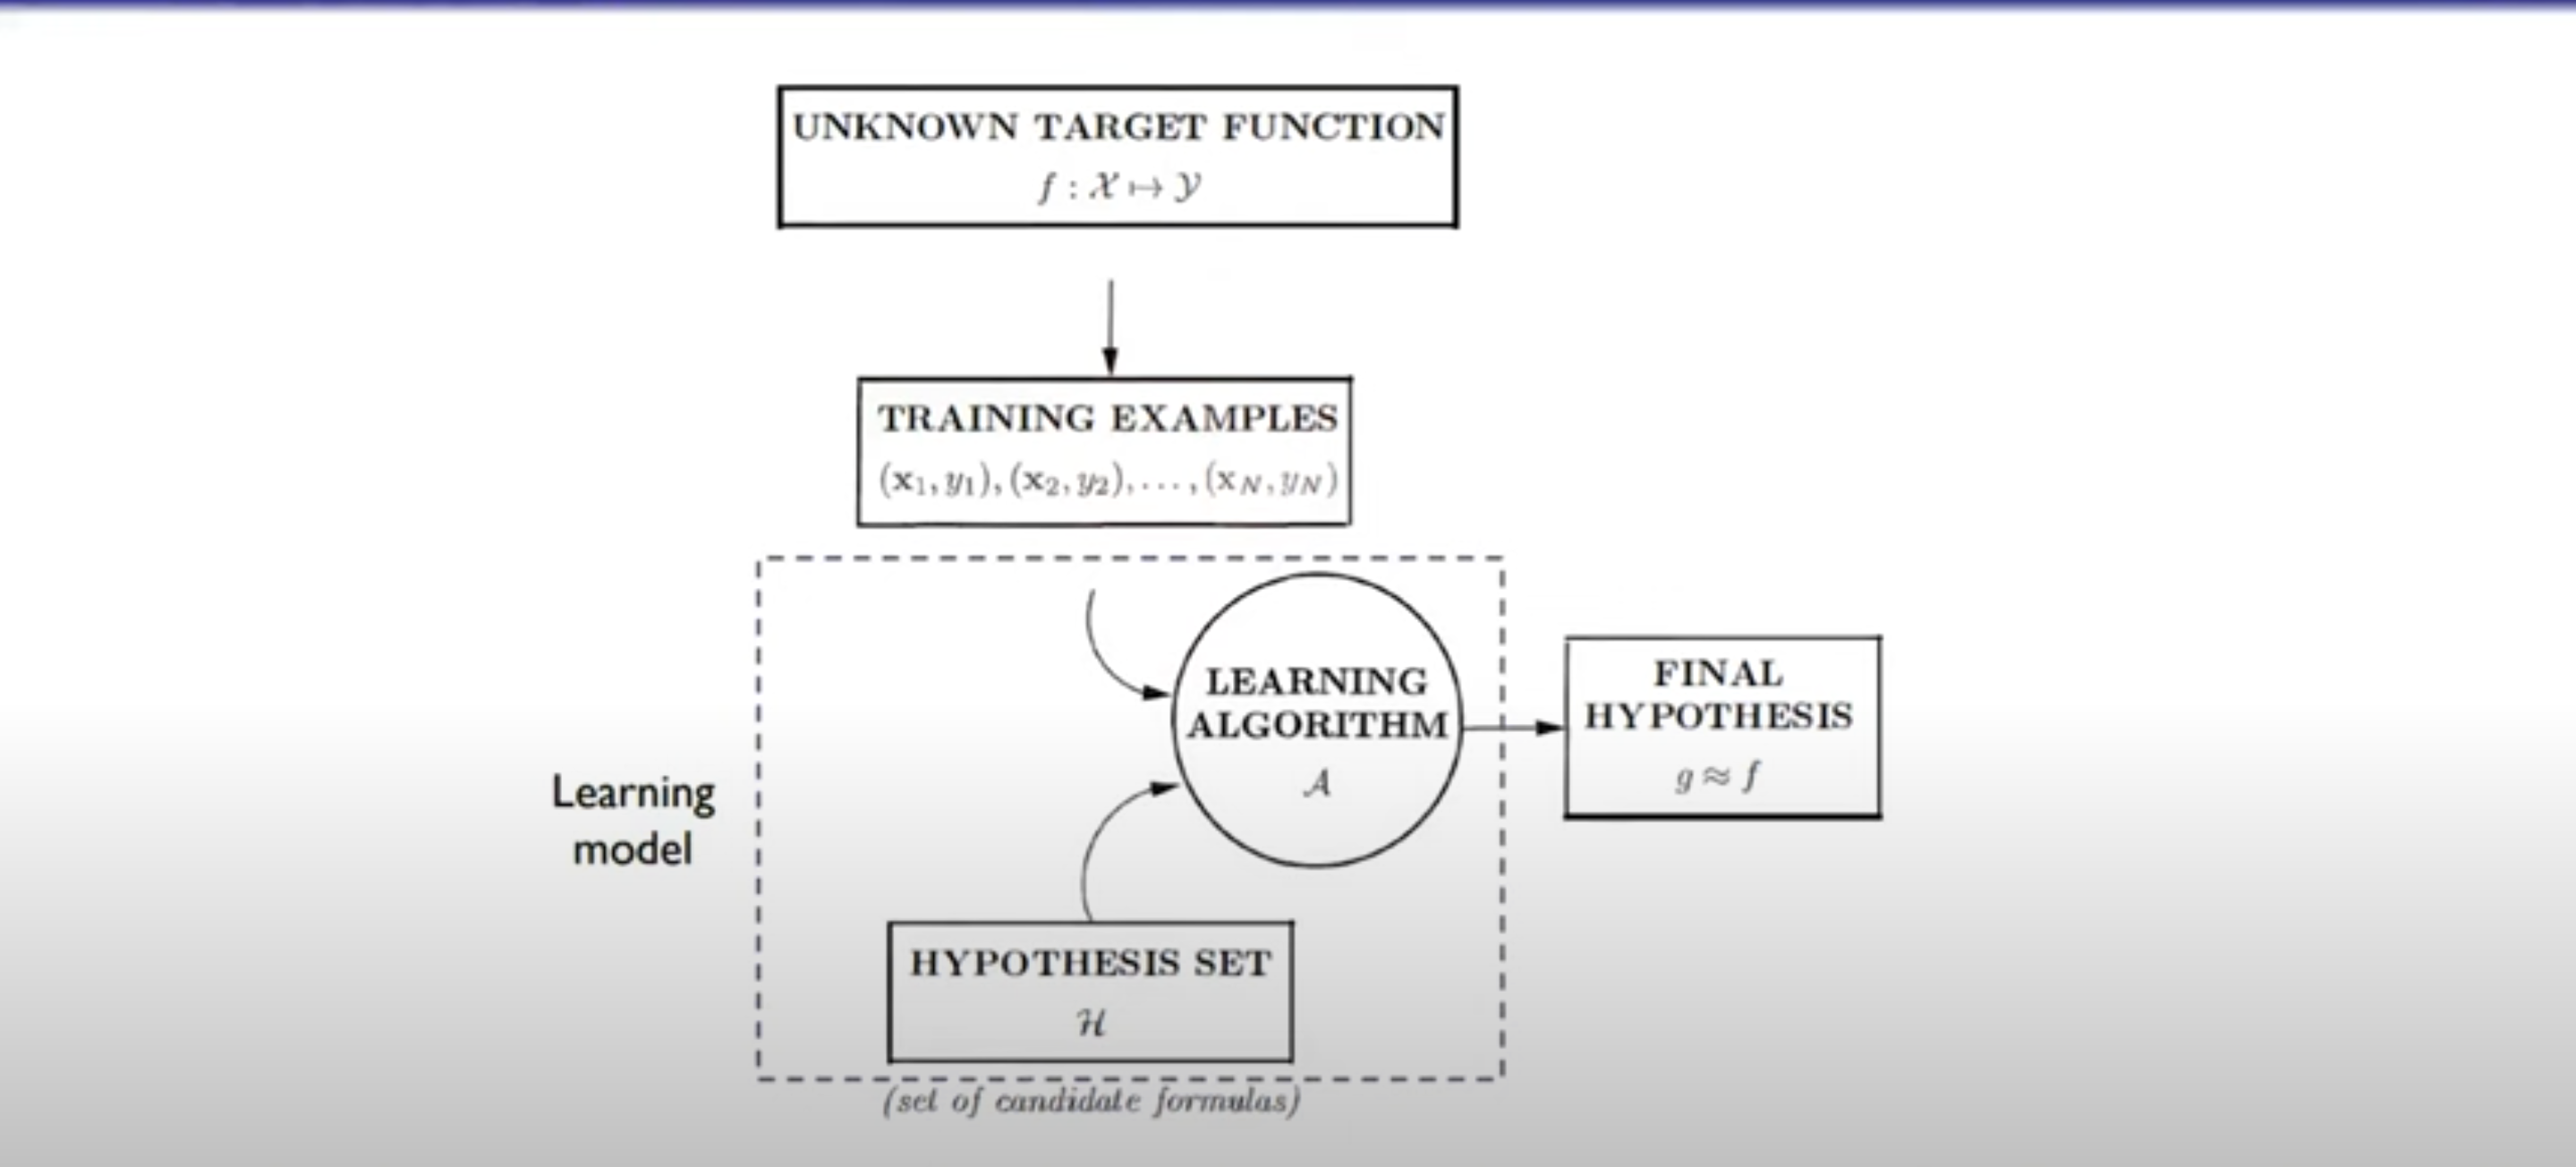

So we have a hypothesis set (set of all the possible functions, models) and a training example (set of training data) and we're gonna use these to teach our model and we also have a learning algorithm and would choose one of the hypothesis based on the **training data**, and would choose the appropriate **parameters** and results in a **final hypothesis**.
If you look at the top of the picture we have an *Unknown Target Function* which is the main function that determines the target feature based on other features and we do not have access to it and we don't know it and we wanna learn it. We wanna find a hypothesis that is closer to the real function.



**Just a quick review**:

+ **Rgression**: predict a *continuous* target variable
    + E.g., $y \in [0,1]$
+ **Classification**: predict a *discrete* target variable
    + E.g., $y \in \{1, 2, ...., C\}$


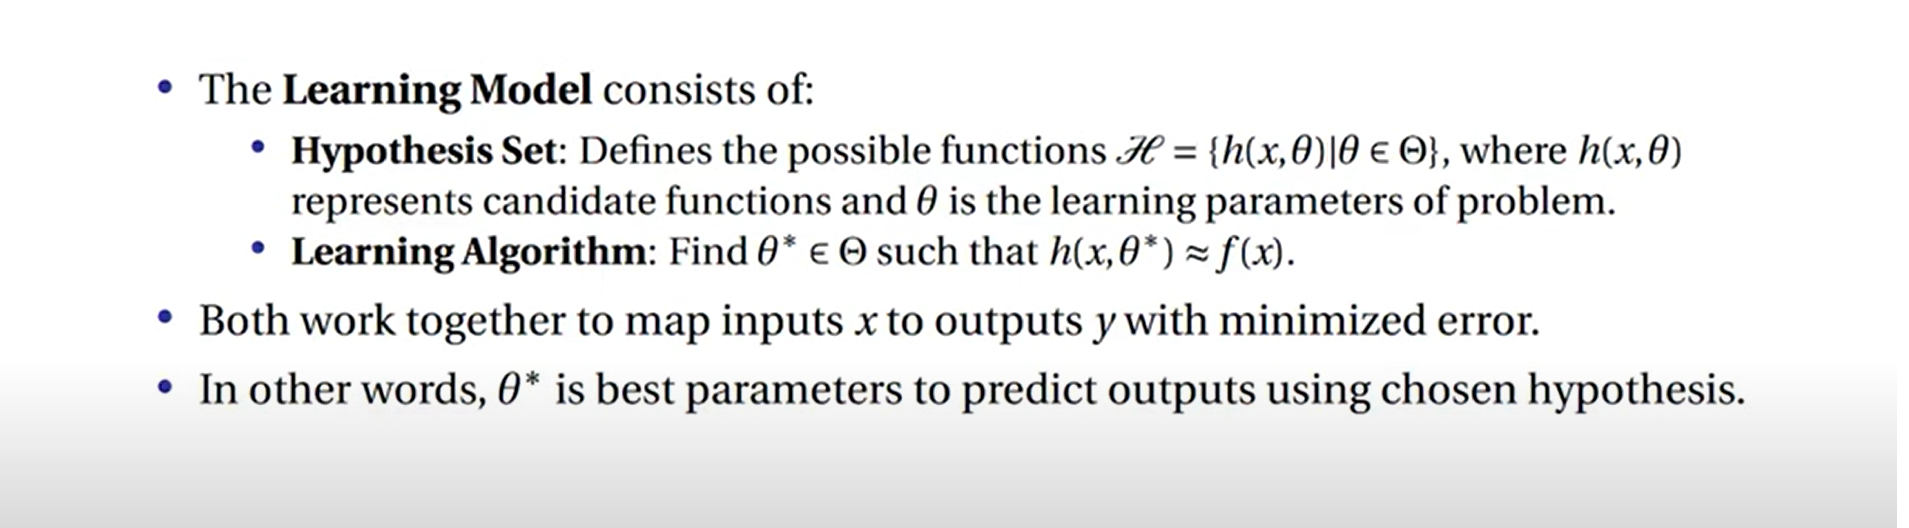


> We are learning the parameters of our model.

+ **Hypothesis(h)**: A mapping from input space $\mathscr{x}$ to output space $\mathscr{y}$.
+ **Linear Regression Hypothesis**:
$$h_w(x) = w_0 + w_1.x_1 + ... + w_D.x_D = w^T.x$$
+ **Input Vector x**:
$$x = [x_0 = 1, x_1,x_2,...,x_D]$$
+ **Parameter Vector w**:
$$w = [w_0,w_1,w_2,...w_D]$$

+ **Linear Hypothesis Space:**
    + **Simple form**: Linear combination of input features.
    $$h_w(x) = w_0 + \sum_{i=1}^{D} w_i x_i



> So what we're trying to do is to pick the best parameters from all the parameters in our hypothesis set. The hypothesis that would make a better/more precise prediction.

The question is how we're going to quantify the "better/more precise prediction"? That is where we will get introduce to **cost function**.

**Cost Function**:
+ In **hypothesis space**, we select a function $h(x; w)$ to approximate the true relationship between input $x$ and output $y$.
+ The objective is to minimize the difference between predicted values $h(x)$ and actual value $y$.
+ This difference is qunatified using **cost function**, which guide us in choosing the optimal hypothesis.

> The more our prediction is better our cost is smaller. and vise verca if the prediction is not good the cost is bigger.


Now we're looking for a set of parameters that would result in an optimal cost (which is the lowest cost possible), which means an optimization problem or a minimization problem.

+ A **cost function** measures how well the hypothesis fits the training data.
+ In `regression` problems, the most common error function is the **Squared Error(SE)**:
$$SE:(y^{(i)} - h(x^{(i)}; w))^2$$
+ Cost function should measure all predictions. Thus a choice could be **Sum of Squared Error(SSE)**: 
$$J(w) = \sum_{i=1}^{D} (y^{(i)} - h(x^{(i)}; w))^2$$
+ Intuitively, it represents the squared distance between predicted and true values.
+ **Objective**: Minimize the cost function to find the best parameters **w**.

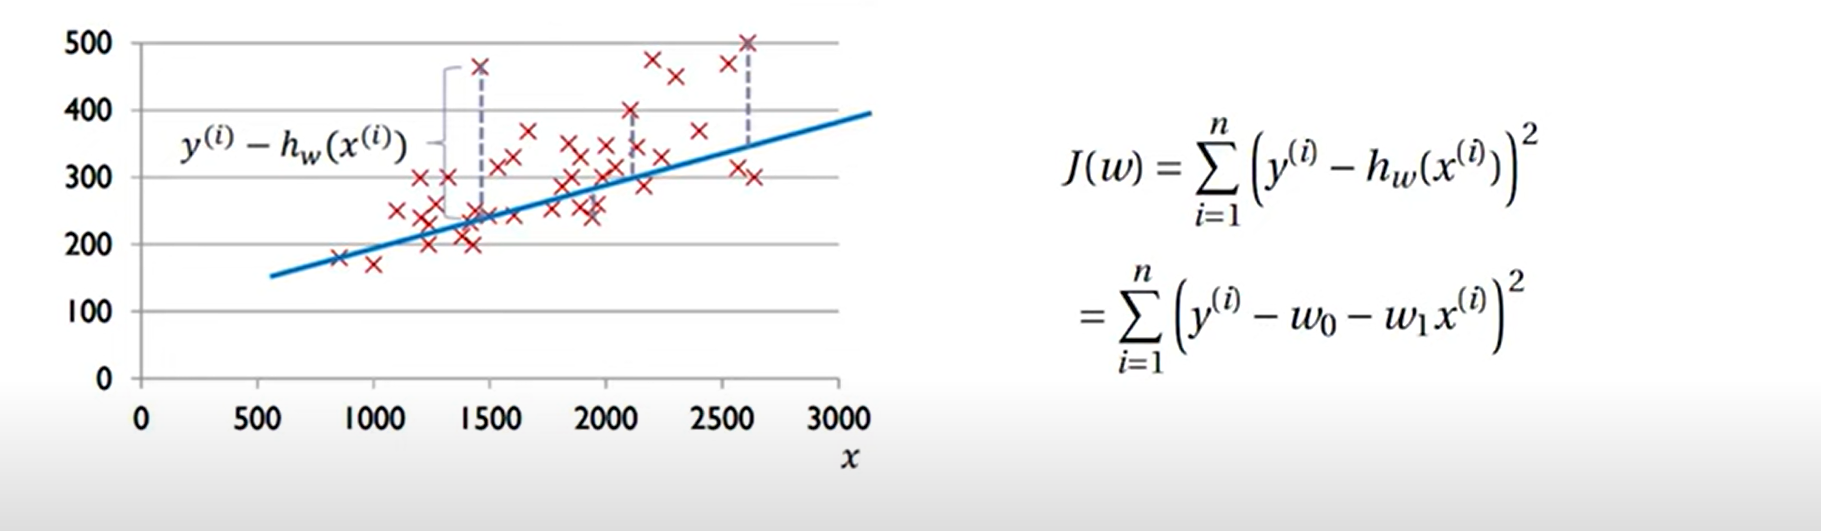

What is our purpose now? 

+ To choose a $w$ so as to minimize the $J(w)$.
+ We wanna optimize the cost function. Explicitly taking the cost function derivation with respect to the $w_i$'s, and setting them to zero.
+ Parameters of the best hypothesis for the training set:
$$w^* = \operatorname*{argmin}_w J(w)$$

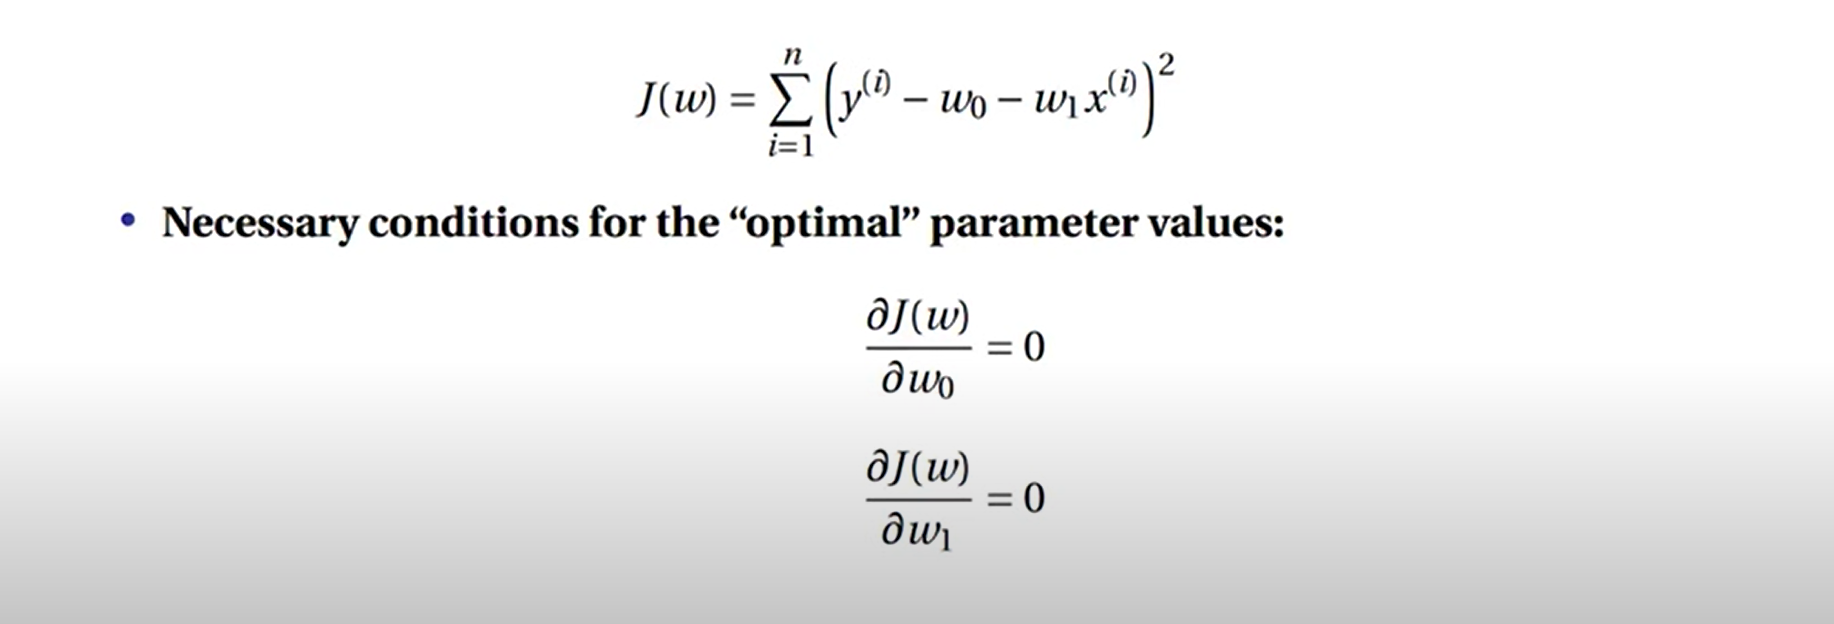

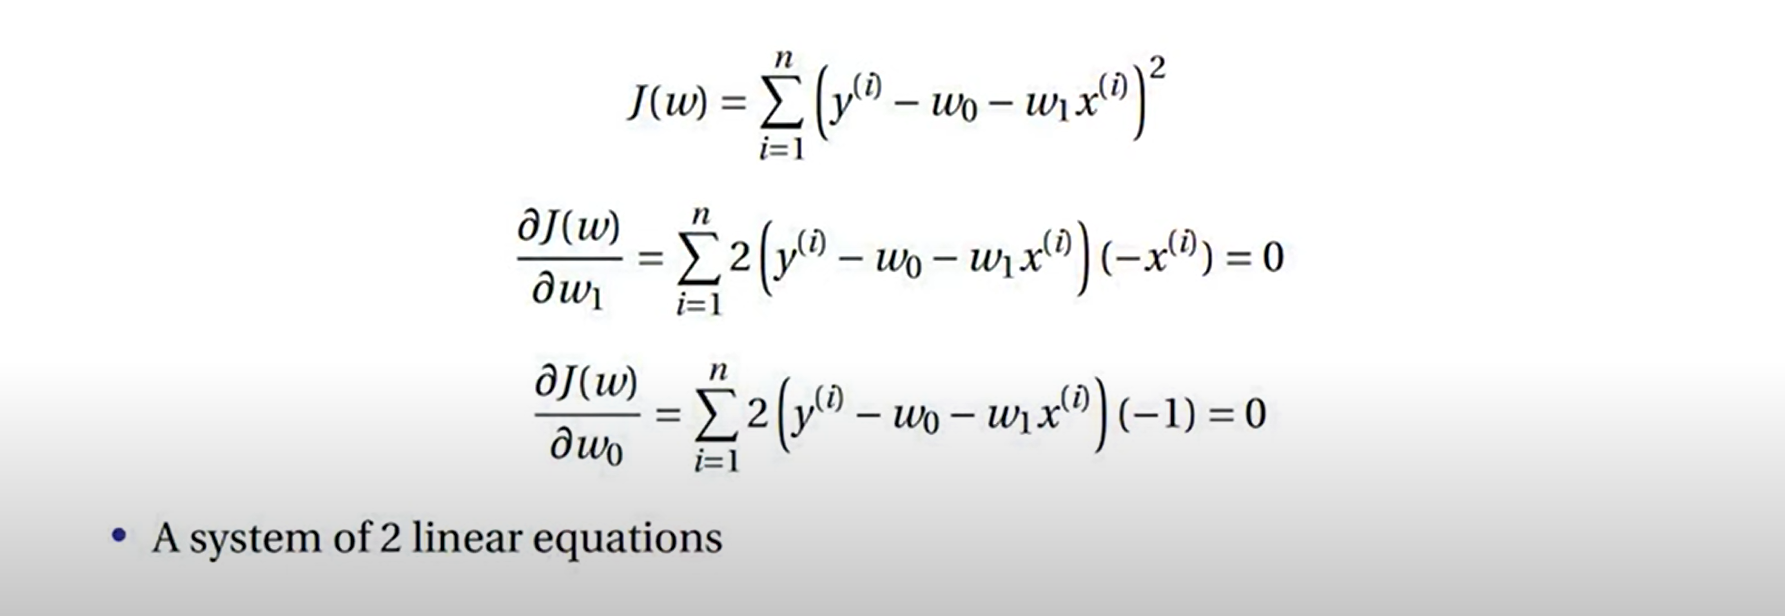  

> Linear Regression can be extended to model nonlinear relationships by introducing polynomial terms.

### A simple regression Example:

In the two following examples we have created some random values to show how we're gonna get our parameters from the hypothesis space that would fit to the data best. and in these examples we are dealing with one dimension problems.

In [1]:
x = [5, 3, -1, 2, 6]
y = [14, 6, -5.5, 3.5, 18]
print(x, y)

[5, 3, -1, 2, 6] [14, 6, -5.5, 3.5, 18]


In [4]:
X, Y, XiYi, Xi2 = 0, 0, 0, 0
n = len(x)
for i in range(n):
    X = X + x[i]
    Y = Y + y[i]
    XiYi = XiYi + (x[i] * y[i])
    Xi2 = Xi2 + x[i] ** 2 
print(n, X, Y, XiYi, Xi2)

5 15 36.0 208.5 75


In [5]:
w1 = (n * XiYi - X * Y) / (n * Xi2 - X**2)
print(w1)

3.35


In [ ]:
w0 = (Y - w1*X)/n
print(w0)

-2.85


### Another example but here with 1000 data other than 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # for 3D plot 
from sklearn import datasets

In [ ]:
# Simulating Data
n = 1000
x = np.random.normal(3, 5, size=n) # for generating 1000 data with a normal distribution
y = -15 * x + 20 + np.random.normal(0, 3, size=n)  # the genrated numbers are the noises

In [9]:
# Analytical approach for solving linear regression
X = np.sum(x)
Y = np.sum(y)
b1 = (n * np.dot(x, y) - Y*X)/(n*np.dot(x, x) - X**2)
b0 = (Y - b1*X)/n
b1, b0 = round(b1, 2), round(b0, 2)
print(f"y = {b1} x + {b0}")

y = -15.0 x + 20.06


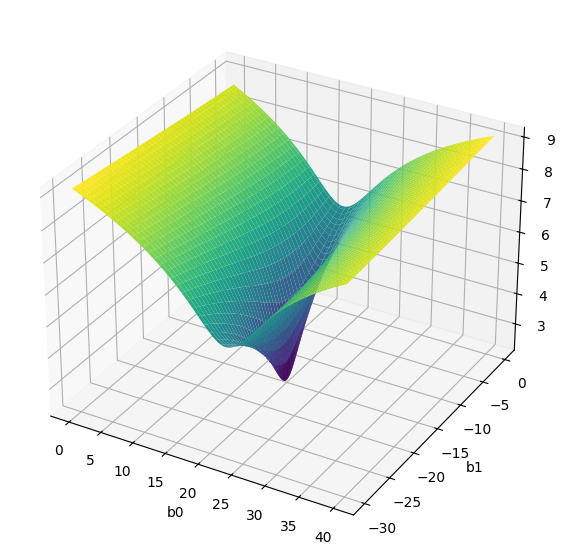

In [17]:
def MSE_loss(b0, b1, x, y):
    pred = b0 + b1 * x
    loss = np.sum((pred - y) ** 2) / len(y)
    return loss


# Generate a grid of b0 and b1 values around the real b0=20 and b1=15
b0_vals = np.linspace(0, 40, 100)
b1_vals = np.linspace(-30, 0, 100)

# Calculate MSE loss for each point of this grid
# Log-scale is used only for better visualization
Z = np.zeros((len(b0_vals), len(b1_vals)))
for i in range(len(b0_vals)):
    for j in range(len(b1_vals)):
        Z[i, j] = np.log(MSE_loss(b0_vals[i], b1_vals[j], x, y))

# 3D plot of MSE loss in long-scale
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
B0, B1 = np.meshgrid(b0_vals, b1_vals)
ax.plot_surface(B0, B1, Z, cmap='viridis')

# Adding labels
ax.set_xlabel('b0')
ax.set_ylabel('b1')
ax.set_zorder('Loss')
plt.show()

From the generated figure above of our generated training data and loss calculation for each of the parameters in the hypothesis space we can see that we would be getting the minimum loss when we have `b0=20` and `b1=-15` or something close to these values as our parameters based on the generated data.

Now Let's get into the D dimensional problem.

> By `Dimension` we mean the number of features and the length of the feature vector that is going to have an impact in the value/class of the target feature.

Consider that for our first sample the $x^(i)$ get represent as below:
$$x^{(i)} = [200, 194, 44, 549]$$

So In below I have wrote the equations for such D dimensional linear regression problem and later on we're gonna test and implement these equations and calculations with code:

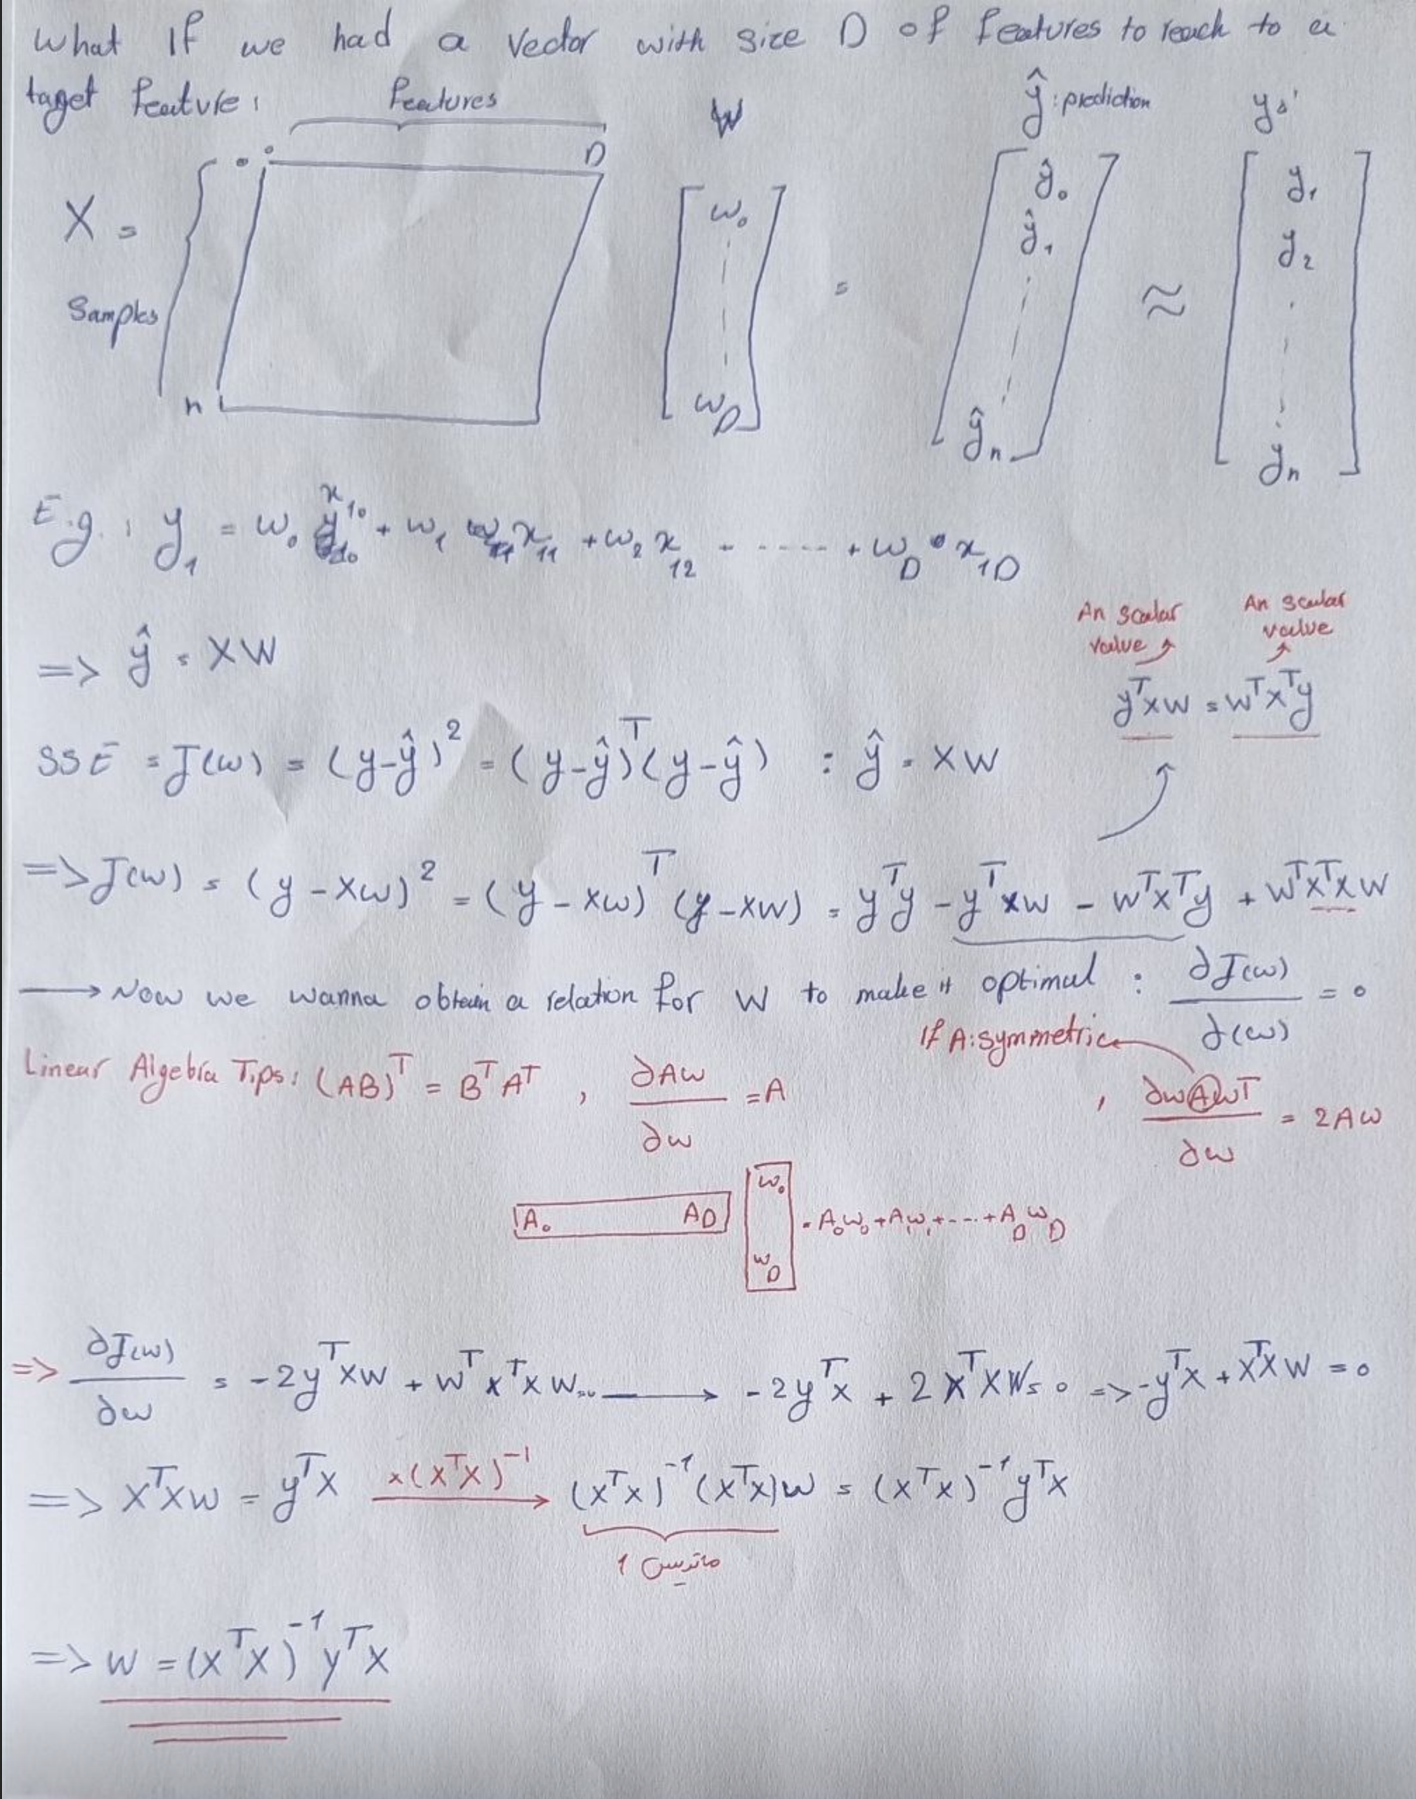

The equation that was found for the `W` is how we're gonna choose teh optimal values for `W` in the hypothesis space.
Now let's get to it's code implementation.




## Gradient Descent algorithm:

Gradient descent is also an optimmization algorithm to optimize a value (here the cost function) and minimize it by constantly calculating the gradient of the loss function based on each parameter and update the parameters' values with a learning rate and the result of the gradient.

For a better understanding of gradient descent you can watch [this](https://www.youtube.com/watch?v=i62czvwDlsw) video to have a better visualize understanding.

for example:
Assuming we need to find $w_0$ and $w_1$ in the problem of linear regression, update rule using gradient descent will be:
$$
\begin{array}{l}
w_0 \leftarrow w_0 - \eta \frac{\partial J}{\partial w_0} = w_0 - \eta \sum_{i=1}^{m} (h_w(x^{(i)}) - y^{(i)}) \\
w_1 \leftarrow w_1 - \eta \frac{\partial J}{\partial w_1} = w_1 - \eta \sum_{i=1}^{m} (h_w(x^{(i)}) - y^{(i)}) (x^{(i)}) \\
\end{array}
$$

In which $ \eta $ is the learning rate.
In below you will be able to see the code implementation of the gradient descent example above:


In [ ]:

# Hypothesis: h_w(x) = w_0 + w_1 * x_1
def h_w(x, w):
    return w[0] + w[1] * x

# SSE cost function
def cost_function(X, y, w):
    return np.sum((h_w(X, w) - y) ** 2) / len(X)


# Gradient Descent
def gradient_descent(X, y, w, alpha, num_iters):
    m = len(X)
    cost_history = []
    w_history = [w.copy()]

    for i in range(num_iters):
        #updates
        gradient_w0 = np.sum(h_w(X, w) - y) / m
        gradient_w1 = np.sum((h_w(X, w) - y) * X) / m
        w[0] -= alpha * gradient_w0
        w[1] -= alpha * gradient_w1

        cost_history.append(cost_function(X, y, w))
        w_history.append(w.copy()) # store a copy of w,  not the reference

    return w, cost_history, w_history

**Note**: Choosing $ \eta $ could be tricky. Large Learning rates can lead to divergence. Small learning rates on the other hand could slow down the convergence by requiring more iterations.